# Mini-Project 2 — MediCare Outpatient Visits: End-to-End Data Analysis
**Python for Full Stack Data Science with AI & Generative AI · Naresh IT**
*Lead Trainer: Ajit Byru · 3 × 90-minute sessions after Module 15*

**The business problem.** MediCare's hospital administrator has one year of outpatient visit records (`clinic_visits_2025.csv`, ~2,400 visits) and four questions she cannot answer from the billing screen: *Where are patients waiting longest? Which departments actually earn what? Is the clinic getting busier? And what should we change in 2026?*

You are the analyst. **Deliverable:** this notebook, cleaned and complete; a one-paragraph recommendation; a 5-slide summary; a 2-minute pitch.

**Rules:** no `sklearn`, no models — insight, not prediction. Every cleaning decision is written down in the Data-Quality Log. Every question ends in a chart.

| Session | Focus | Sections |
|---|---|---|
| 1 | Load · profile · clean | 1–2 |
| 2 | Five guided questions | 3 |
| 3 | Your own question · recommendation · pitch | 4–6 |

---
## Session 1 — Section 1: Load and profile

Before cleaning anything, *look*. `shape`, `head`, `info`, `describe`, `isna`, `duplicated`, `value_counts` — the profiling checklist from Module 14. Write down every problem you find **before** fixing any of them.

### 1.1 Load
Read the CSV and print its shape and first rows.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

raw = pd.read_csv("clinic_visits_2025.csv")
print(raw.shape)
raw.head()
raw.tail()

(2423, 13)


,visit_id,patient_id,visit_date,department,doctor,age,gender,city,wait_minutes,consult_minutes,fee,payment_mode,follow_up
2418,V101698,P1032,15/07/2025,Orthopedics,Dr. Nair,73,F,Secunderabad,5,20,910.0,UPI,No
2419,V100333,P1630,2025-05-26,Pediatrics,Dr. Reddy,12,F,Secunderabad,12,16,610.0,Insurance,No
2420,V101294,P1091,20/03/2025,General Medicine,Dr. Pillai,26,M,Secunderabad,19,16,430.0,Cash,No
2421,V101105,P1418,06-Oct-2025,Orthopedics,Dr. Nair,51,M,Hyderabad,32,19,960.0,UPI,No
2422,V101946,P1025,2025-09-12,General Medicine,Dr. Bose,54,M,Vijayawada,46,26,490.0,UPI,No


### 1.2 `info()` — which columns are the wrong type?
🔮 **PREDICT:** `visit_date` should be a datetime. Will it be?

In [2]:
# YOUR CODE HERE
# Hint: raw.info()

raw.info()


<class 'pandas.DataFrame'>
RangeIndex: 2423 entries, 0 to 2422
Data columns (total 13 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   visit_id         2423 non-null   str    
 1   patient_id       2423 non-null   str    
 2   visit_date       2423 non-null   str    
 3   department       2423 non-null   str    
 4   doctor           2423 non-null   str    
 5   age              2423 non-null   int64  
 6   gender           2423 non-null   str    
 7   city             2423 non-null   str    
 8   wait_minutes     2423 non-null   int64  
 9   consult_minutes  2423 non-null   int64  
 10  fee              2303 non-null   float64
 11  payment_mode     2423 non-null   str    
 12  follow_up        2423 non-null   str    
dtypes: float64(1), int64(3), str(9)
memory usage: 386.9 KB


### 1.3 `describe()` — anything impossible?
Look at `min` and `max` of every numeric column. A hospital dataset has physical limits.

In [3]:
# YOUR CODE HERE
# Hint: raw.describe()
raw[["age", "wait_minutes", "consult_minutes", "fee"]].describe()


,age,wait_minutes,consult_minutes,fee
count,2423.000000,2423.000000,2423.000000,2303.000000
mean,45.039208,28.637639,17.881965,1076.126791
std,24.484135,11.908123,6.252076,3697.973219
min,0.000000,-37.000000,5.000000,430.000000
25%,27.000000,21.000000,13.000000,560.000000
50%,45.000000,28.000000,18.000000,730.000000
75%,64.000000,37.000000,22.500000,1025.000000
max,412.000000,64.000000,35.000000,50000.000000


### 1.4 Missing values and duplicates

In [4]:
# YOUR CODE HERE
# Hint: raw.isna().sum() and raw.duplicated().sum()
raw.isna().sum()
raw.duplicated().sum()
print("Missing values:\n", raw.isna().sum())
print("\nDuplicate rows:", raw.duplicated().sum())



Missing values:
 visit_id             0
patient_id           0
visit_date           0
department           0
doctor               0
age                  0
gender               0
city                 0
wait_minutes         0
consult_minutes      0
fee                120
payment_mode         0
follow_up            0
dtype: int64

Duplicate rows: 23


### 1.5 Category hygiene
`value_counts()` on `department`. How many departments does MediCare *actually* have?

In [5]:
# YOUR CODE HERE
# Hint: raw["department"].value_counts()
print(raw["department"].value_counts())


department
General Medicine      784
Cardiology            375
Orthopedics           370
Dermatology           311
Pediatrics            302
ENT                   221
general medicine        8
 GENERAL MEDICINE       8
cardiology              8
 DERMATOLOGY            6
ent                     6
orthopedics             5
 ORTHOPEDICS            4
 ENT                    4
 CARDIOLOGY             4
 PEDIATRICS             4
dermatology             3
Name: count, dtype: int64


In [6]:
# First, clean up the data we have so far
df = raw.drop_duplicates().copy()
df["department"] = df["department"].astype(str).str.strip().str.title()

print("CELL 2.3: THE TRAP")
print("=" * 50)

# Try the simple way (THIS IS THE TRAP!)
dates_trap = pd.to_datetime(df["visit_date"], format="mixed", dayfirst=True)

# Look at what day of the week each date is
days = dates_trap.dt.day_name()
print("\nDays of the week:")
print(days.value_counts())

# Check: How many Sundays?
sunday_count = (days == "Sunday").sum()
print(f"\nSunday visits: {sunday_count}")
print("⚠️  PROBLEM! MediCare is CLOSED on Sunday")
print("⚠️  If there are Sundays, the dates are WRONG\n")


CELL 2.3: THE TRAP

Days of the week:
visit_date
Monday       459
Friday       410
Tuesday      408
Wednesday    380
Thursday     355
Saturday     305
Sunday        83
Name: count, dtype: int64

Sunday visits: 83
⚠️  PROBLEM! MediCare is CLOSED on Sunday
⚠️  If there are Sundays, the dates are WRONG



### 1.6 Peek at the dates
Sample a few raw `visit_date` strings. How many different formats can you see?

In [7]:
# YOUR CODE HERE
# Hint: raw["visit_date"].sample(8, random_state=1).tolist()
raw["visit_date"].sample(8, random_state=1).tolist()



['21/06/2025',
 '2025-04-02',
 '2025-11-11',
 '2025-11-06',
 '14/11/2025',
 '2025-12-25',
 '2025-10-02',
 '2025-08-14']

### 📝 Data-Quality Log (fill this in — it is graded)
Record every problem found in 1.1–1.6. Add the fix and reasoning as you clean in Section 2.

| # | Problem found | Rows affected | Fix applied | Why this fix (not another) |
|---|---|---|---|---|
| 1 | | | | |
| 2 | | | | |
| 3 | | | | |
| 4 | | | | |
| 5 | | | | |
| 6 | | | | |
| 7 | | | | |

---
## Section 2: Clean

Work on a **copy** (`df = raw.drop_duplicates().copy()`) so `raw` stays untouched for comparison. Order matters: duplicates first (so counts are honest), then text, dates, ranges, outliers, and finally imputation.

### 2.1 Duplicates
Drop exact duplicate rows. Print before / after / removed.

In [8]:
# YOUR CODE HERE
# Hint: df = raw.drop_duplicates().copy()
df = raw.drop_duplicates().copy()
print(df)

     visit_id patient_id   visit_date        department      doctor  age  \
0     V101246      P1873   24/11/2025        Pediatrics     Dr. Das    1   
1     V101350      P1692   2025-04-28       Dermatology   Dr. Menon   54   
2     V102168      P1159   2025-01-31  General Medicine    Dr. Bose   53   
3     V101745      P1195  23-Jan-2025       Dermatology   Dr. Menon   79   
4     V101334      P1709   2025-08-25       Orthopedics    Dr. Nair   40   
...       ...        ...          ...               ...         ...  ...   
2418  V101698      P1032   15/07/2025       Orthopedics    Dr. Nair   73   
2419  V100333      P1630   2025-05-26        Pediatrics   Dr. Reddy   12   
2420  V101294      P1091   20/03/2025  General Medicine  Dr. Pillai   26   
2421  V101105      P1418  06-Oct-2025       Orthopedics    Dr. Nair   51   
2422  V101946      P1025   2025-09-12  General Medicine    Dr. Bose   54   

     gender          city  wait_minutes  consult_minutes    fee payment_mode  \
0      

### 2.2 Department names
Strip whitespace and standardise case. Then check the result — did the standardisation break anything?

In [9]:
# YOUR CODE HERE
# Hint: .str.strip().str.title()  -- then look at the unique values carefully
df = raw.drop_duplicates().copy()

df["department"] = df["department"].astype(str).str.strip().str.title()
df["department"].value_counts()


department
General Medicine    792
Cardiology          384
Orthopedics         375
Dermatology         318
Pediatrics          304
Ent                 227
Name: count, dtype: int64

### 2.3 Dates — the trap
Three formats live in one column. The tempting one-liner is `pd.to_datetime(..., format="mixed", dayfirst=True)`. Run it and look at the weekday distribution.

🔮 **PREDICT:** MediCare is closed on Sundays. How many Sunday visits should there be?

In [10]:
# [TRAP] The obvious one-liner. Looks fine...


parsed = pd.to_datetime(df["visit_date"], format="mixed", dayfirst=True)
#date time  =  
print(parsed.dtype)
print("Range:", parsed.min().date(), "to", parsed.max().date())
print(parsed.dt.day_name().value_counts())


datetime64[us]
Range: 2025-01-01 to 2025-12-31
visit_date
Monday       459
Friday       410
Tuesday      408
Wednesday    380
Thursday     355
Saturday     305
Sunday        83
Name: count, dtype: int64


### 2.4 Investigate
Compare the ISO-formatted strings with what the parser produced.

In [11]:
# YOUR CODE HERE
# Hint: build a mask for ISO-looking strings with .str.match(r"\d{4}-\d{2}-\d{2}$"); compare parsed.dt.strftime("%Y-%m-%d") with the text

import pandas as pd

# Find ISO dates using string matching
is_iso = df["visit_date"].str.len() == 10
iso_df = df[is_iso].copy()

print(f"Found {len(iso_df)} ISO dates\n")

# Parse and compare
iso_df["parsed"] = pd.to_datetime(iso_df["visit_date"], format="mixed", dayfirst=True)
iso_df["parsed_str"] = iso_df["parsed"].dt.strftime("%Y-%m-%d")
iso_df["match"] = iso_df["visit_date"] == iso_df["parsed_str"]

# Show results
print(iso_df[["visit_date", "parsed_str", "match"]].head(15))

# Summary
matches = iso_df["match"].sum()
mismatches = (~iso_df["match"]).sum()
print(f"\nMatches: {matches}, Mismatches: {mismatches}")

Found 2154 ISO dates

    visit_date  parsed_str  match
0   24/11/2025  2025-11-24  False
1   2025-04-28  2025-04-28   True
2   2025-01-31  2025-01-31   True
4   2025-08-25  2025-08-25   True
5   2025-12-30  2025-12-30   True
6   2025-11-12  2025-12-11  False
8   2025-10-31  2025-10-31   True
10  2025-02-12  2025-12-02  False
12  2025-03-04  2025-04-03  False
13  2025-04-09  2025-09-04  False
14  2025-02-07  2025-07-02  False
15  2025-03-06  2025-06-03  False
16  05/03/2025  2025-03-05  False
17  2025-03-31  2025-03-31   True
18  2025-04-14  2025-04-14   True

Matches: 1087, Mismatches: 1067


### 2.5 Fix — parse each format explicitly
Write a function that tries each format in turn with `errors="coerce"` and fills gaps. Verify: zero unparsed, zero Sundays.

In [12]:
# YOUR CODE HERE
# Hint: pd.to_datetime(s, format="%Y-%m-%d", errors="coerce") then .fillna(...) with the next format

import pandas as pd

s = pd.Series(["2025-05-27", "19/11/2025", "06-May-2025"])

# Attempt 1: try ISO format. Anything that doesn't match becomes NaT.
attempt1 = pd.to_datetime(s, format="%Y-%m-%d", errors="coerce")
print(attempt1)

0   2025-05-27
1          NaT
2          NaT
dtype: datetime64[us]


### 2.6 Impossible ages
Find ages ≤ 0 or > 110. Decide: repair or reject? (There is no way to recover a true age — reject, and record the visit_ids.)

In [13]:
# YOUR CODE HERE
# Hint: (df["age"] <= 0) | (df["age"] > 110)

# Find impossible ages (≤ 0 or > 110)
bad_ages = df[(df["age"] <= 0) | (df["age"] > 110)]

print(f"Found {len(bad_ages)} impossible ages\n")
print(bad_ages[["visit_id", "age"]])

# DECISION: REJECT (delete them)
print(f"\n✓ DECISION: DELETE these {len(bad_ages)} rows")

print(f"\nRemaining rows: {len(df)}")


Found 3 impossible ages

     visit_id  age
1629  V101228    0
2032  V102161  412
2251  V102242  199

✓ DECISION: DELETE these 3 rows

Remaining rows: 2400


### 2.7 Negative wait times
A negative wait is a sign error at data entry, not a real value. Decide: repair (`abs`) or reject? Justify in the log.

In [14]:
# YOUR CODE HERE
# Hint: df.loc[mask, "wait_minutes"] = ...abs()

# Find negative wait times
negative_waits = df[df["wait_minutes"] < 0]

print(f"Found {len(negative_waits)} negative waits\n")
print(negative_waits[["visit_id", "wait_minutes"]])

# FIX: Use abs() to take absolute value
print(f"\n✓ Fixing {len(negative_waits)} rows with abs()")
df.loc[df["wait_minutes"] < 0, "wait_minutes"] = abs(df.loc[df["wait_minutes"] < 0, "wait_minutes"])

print(f" Done! Wait time range: {df['wait_minutes'].min()} to {df['wait_minutes'].max()} minutes")




Found 5 negative waits

     visit_id  wait_minutes
275   V101848           -33
706   V100673           -37
1152  V100087           -33
1338  V102141           -36
1474  V101975           -21

✓ Fixing 5 rows with abs()
 Done! Wait time range: 3 to 64 minutes


### 2.8 Fee outliers — the judgement call
Apply the 1.5 × IQR fence from Module 15. Then **look at what it flags** before doing anything.

In [15]:
# YOUR CODE HERE
# Hint: df["fee"].quantile([0.25, 0.75]); fence = q3 + 1.5*iqr; 
# look at department and unique fee values of flagged rows

# Calculate IQR
q1 = df["fee"].quantile(0.25)
q3 = df["fee"].quantile(0.75)
iqr = q3 - q1
upper = q3 + 1.5 * iqr
flagged = df[df["fee"] > upper]
print(f"Q1 = {q1},| Q3 = {q3},| IQR = {iqr},| upper limit = {upper}")
print("Rows above limit :", len(flagged))
print(flagged["department"].value_counts())
print(flagged["fee"].unique())

Q1 = 560.0,| Q3 = 1030.0,| IQR = 470.0,| upper limit = 1735.0
Rows above limit : 13
department
Orthopedics    7
Cardiology     6
Name: count, dtype: int64
[50000.]


### 2.9 Decide
The fence flags them. Are they errors? Look at the values and the departments. Write your decision in the log.

In [16]:
# YOUR CODE HERE
# Hint: df["is_procedure"] = ...

# Create column to mark procedures
df["is_procedure"] = False

# Find outliers again (same as 2.8)
q1 = df["fee"].quantile(0.25)
q3 = df["fee"].quantile(0.75)
iqr = q3 - q1
fence = q3 + 1.5 * iqr

outliers = df[df["fee"] > fence]

# Mark outliers as procedures
df.loc[df["fee"] > fence, "is_procedure"] = True

print("Marked " + str(len(outliers)) + " high-fee visits as is_procedure = True")
print("")

# Show the split
regular = (df["is_procedure"] == False).sum()
procedures = (df["is_procedure"] == True).sum()

print("Regular consultations: " + str(regular))
print("Procedures: " + str(procedures))
print("Total: " + str(len(df)))

print("")
print("REASONING:")
print("- High fees are PROCEDURES (surgery, imaging, etc)")
print("- Not billing errors")
print("- We analyze them separately from regular visits")



Marked 13 high-fee visits as is_procedure = True

Regular consultations: 2387
Procedures: 13
Total: 2400

REASONING:
- High fees are PROCEDURES (surgery, imaging, etc)
- Not billing errors
- We analyze them separately from regular visits


### 2.10 Missing fees
Impute with a median — but *which* median? 🔮 **PREDICT:** What goes wrong if you use the overall median for a Cardiology visit?

In [17]:
# YOUR CODE HERE
# Hint: dept_median = df.groupby("department")["fee"].median(); df["department"].map(dept_median)
print(f"Overall median: ₹{df['fee'].median():.0f}\n")
print(df.groupby("department")["fee"].median())


Overall median: ₹730

department
Cardiology          1260.0
Dermatology          850.0
Ent                  740.0
General Medicine     520.0
Orthopedics         1060.0
Pediatrics           630.0
Name: fee, dtype: float64


### 2.11 Derived columns and save
Add `weekday` and `month`. Save `clinic_visits_clean.csv`. Print the final shape — this is your acceptance number.

In [18]:
# YOUR CODE HERE
# Hint: df["visit_date"].dt.day_name(), .dt.month; df.to_csv("clinic_visits_clean.csv", index=False)
# CELL 2.11: DERIVED COLUMNS & SAVE

# First, convert visit_date to datetime if not already done
print("Converting visit_date to datetime...")
df["visit_date"] = pd.to_datetime(df["visit_date"], format="mixed", dayfirst=True)
print("✓ Converted")

# Add weekday column
df["weekday"] = df["visit_date"].dt.day_name()
print("✓ Added weekday column")

# Add month column
df["month"] = df["visit_date"].dt.month
print("✓ Added month column")

# Save to CSV
df.to_csv("clinic_visits_clean.csv", index=False)
print("✓ Saved to: clinic_visits_clean.csv")

# Show final shape
print("")
print("FINAL SHAPE: " + str(df.shape[0]) + " rows × " + str(df.shape[1]) + " columns")
print("")
print("=" * 50)
print("✓ DATA CLEANING COMPLETE!")
print("=" * 50)


Converting visit_date to datetime...
✓ Converted
✓ Added weekday column
✓ Added month column
✓ Saved to: clinic_visits_clean.csv

FINAL SHAPE: 2400 rows × 16 columns

✓ DATA CLEANING COMPLETE!


---
## Session 2 — Section 3: Five guided questions

Each question ends in a chart with a title, axis labels and a one-sentence reading in the markdown cell below it. **A chart without a sentence is not an answer.**

### Q1. Which department is busiest, and on which weekday?
Two bar charts. Reading: what does Monday mean for staffing?

Busiest dept: General Medicine (792 visits)
Busiest day : Monday (459 visits)


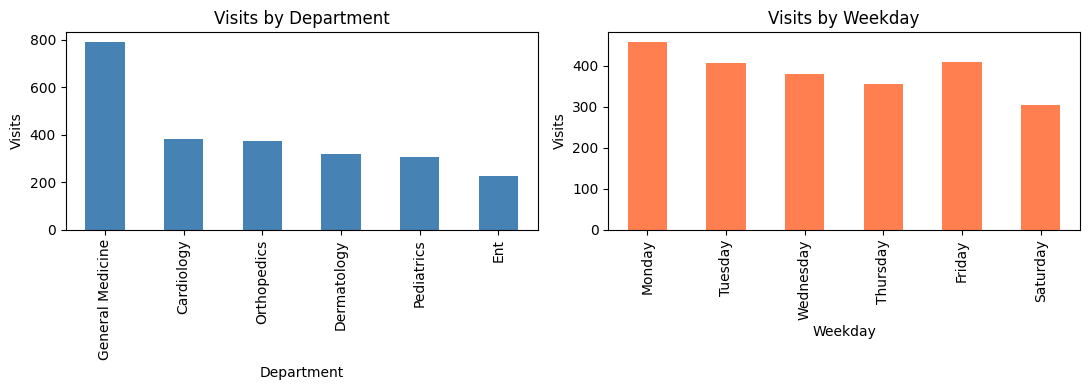

In [19]:
# YOUR CODE HERE
# Hint: value_counts().plot(kind="bar"); reindex weekdays in order

dept = df["department"].value_counts()
order = ["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday"]
days = df["weekday"].value_counts().reindex(order)

print(f"Busiest dept: {dept.index[0]} ({dept.iloc[0]} visits)")
print(f"Busiest day : {days.idxmax()} ({days.max()} visits)")

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
dept.plot(kind="bar", ax=ax[0], color="steelblue")
ax[0].set(title="Visits by Department", xlabel="Department", ylabel="Visits")

days.plot(kind="bar", ax=ax[1], color="coral")
ax[1].set(title="Visits by Weekday", xlabel="Weekday", ylabel="Visits")
plt.tight_layout()
plt.show()



*Reading:*

### Q2. Where do patients wait longest?
Group wait time by department: mean, median, std, and the 90th percentile. Box plot. Reading: which department's *worst* days matter most?

                  mean  median  std   p90
department                               
General Medicine  37.8    38.0  8.9  49.0
Cardiology        31.8    32.0  8.9  43.0
Orthopedics       25.9    26.0  8.8  37.0
Pediatrics        22.1    22.5  8.6  32.0
Ent               20.1    19.0  9.0  32.4
Dermatology       18.4    18.0  8.5  29.3


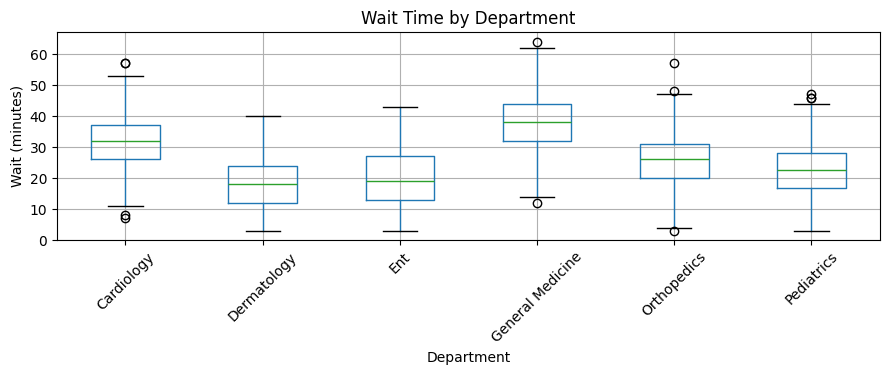

In [20]:
# YOUR CODE HERE
# Hint: groupby("department")["wait_minutes"].agg(mean=..., median=..., std=..., p90=lambda s: s.quantile(0.9)); df.boxplot(column=..., by=...)
wait = df.groupby("department")["wait_minutes"].agg(
    mean="mean", median="median", std="std",
    p90=lambda s: s.quantile(0.90)
).round(1).sort_values("median", ascending=False)

print(wait)

df.boxplot(column="wait_minutes", by="department", figsize=(9, 4))
plt.title("Wait Time by Department"); plt.suptitle("")
plt.xlabel("Department"); plt.ylabel("Wait (minutes)")
plt.xticks(rotation=45); plt.tight_layout(); plt.show()

*Reading:*

### Q3. What does each department really earn per visit?
Mean vs median fee by department, with and without procedures. Reading: which number would you put in the annual report, and why?

                    mean  median      max  mean_no_proc
department                                             
Cardiology        2054.0  1260.0  50000.0        1258.0
Dermatology        846.0   850.0   1000.0         846.0
Ent                735.0   740.0    870.0         735.0
General Medicine   522.0   520.0    620.0         522.0
Orthopedics       2024.0  1060.0  50000.0        1059.0
Pediatrics         632.0   630.0    750.0         632.0


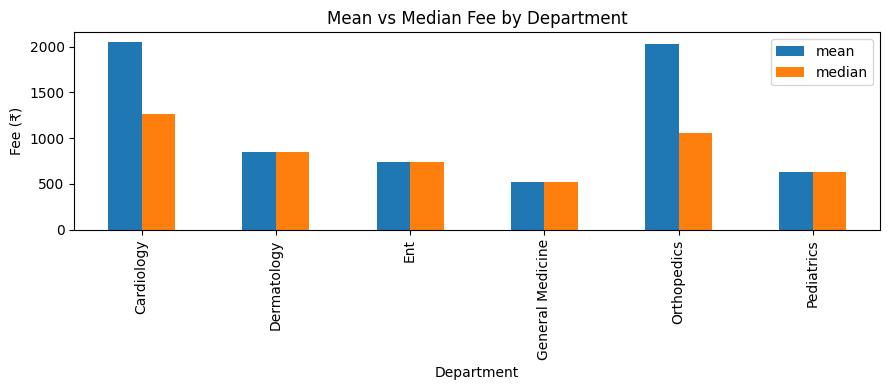

In [21]:
# YOUR CODE HERE
# Hint: agg(mean=..., median=..., max=...) with and without df["is_procedure"]; grouped bar via .plot(kind="bar")

allf = df.groupby("department")["fee"].agg(mean="mean", median="median", max="max")
cons = df[~df["is_procedure"]].groupby("department")["fee"].mean()

out = allf.assign(mean_no_proc=cons).round(0)
print(out)

out[["mean", "median"]].plot(kind="bar", figsize=(9, 4))
plt.title("Mean vs Median Fee by Department")
plt.xlabel("Department"); plt.ylabel("Fee (₹)")
plt.tight_layout(); plt.show()

*Reading:*

### Q4. Does patient age relate to consultation length?
Scatter, `r`, `np.polyfit` line. Reading: how much longer per decade of age?

Correlation r = 0.731
Extra time per decade = 1.9 minutes


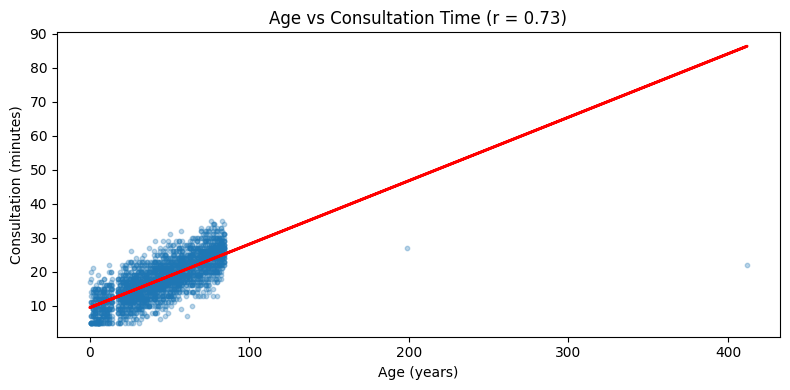

In [22]:
# YOUR CODE HERE
# Hint: np.corrcoef(...)[0, 1]; np.polyfit(..., deg=1); plt.scatter + plt.plot

r = np.corrcoef(df["age"], df["consult_minutes"])[0, 1]
slope, intercept = np.polyfit(df["age"], df["consult_minutes"], 1)

print(f"Correlation r = {r:.3f}")
print(f"Extra time per decade = {slope * 10:.1f} minutes")

plt.figure(figsize=(8, 4))
plt.scatter(df["age"], df["consult_minutes"], alpha=0.3, s=10)
plt.plot(df["age"], slope * df["age"] + intercept, color="red", linewidth=2)
plt.title(f"Age vs Consultation Time (r = {r:.2f})")
plt.xlabel("Age (years)"); plt.ylabel("Consultation (minutes)")
plt.tight_layout(); plt.show()


*Reading:*

### Q5. Is the clinic getting busier? Monthly revenue trend
Line chart, all revenue vs consultations only. Reading: are the spikes growth or single events?

        all  consults_only
month                     
1      1.87           1.37
2      2.30           1.30
3      2.11           1.61
4      1.62           1.62
5      1.57           1.57
6      2.96           1.46
7      1.40           1.40
8      1.54           1.54
9      3.10           1.60
10     2.09           1.59
11     1.98           1.48
12     2.08           1.58


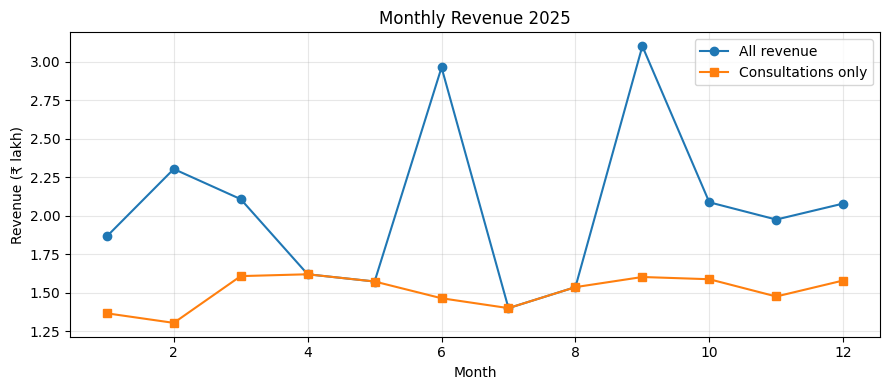

In [23]:
# YOUR CODE HERE
# Hint: groupby("month")["fee"].sum() / 1e5, twice (all / non-procedure); plt.plot with marker

all_rev = df.groupby("month")["fee"].sum() / 1e5
cons_rev = df[~df["is_procedure"]].groupby("month")["fee"].sum() / 1e5

print(pd.DataFrame({"all": all_rev.round(2), "consults_only": cons_rev.round(2)}))

plt.figure(figsize=(9, 4))
plt.plot(all_rev.index, all_rev, marker="o", label="All revenue")
plt.plot(cons_rev.index, cons_rev, marker="s", label="Consultations only")
plt.title("Monthly Revenue 2025")
plt.xlabel("Month"); plt.ylabel("Revenue (₹ lakh)")
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()


*Reading:*

---
## Session 3 — Section 4: Your own question

Pick **one** and take it further than the guided questions did — this is your headline finding and your slide 3.

1. **Doctor workload** — is any doctor carrying an unfair share of visits or wait time within their department?
2. **Follow-up compliance** — which departments/ages come back for follow-up, and which don't?
3. **Payment-mode trends** — is UPI displacing cash across the year? Does mode differ by city or age?
4. **City-wise access** — do out-of-city patients wait longer or pay more?
5. **Consultation efficiency** — wait vs consult ratio by department: where does the queue exceed the care?
6. **Revenue concentration** — what share of revenue comes from the top 10% of visits? Top 2 departments?

Requirements: at least one `groupby`, one chart, one statistic you can defend, and a sentence on what you'd need to be sure.

                  wait  consult  ratio
department                            
Pediatrics        22.5     10.0   2.25
General Medicine  38.0     19.0   2.00
Cardiology        32.0     18.0   1.78
Orthopedics       26.0     19.0   1.37
Ent               19.0     18.0   1.06
Dermatology       18.0     19.0   0.95


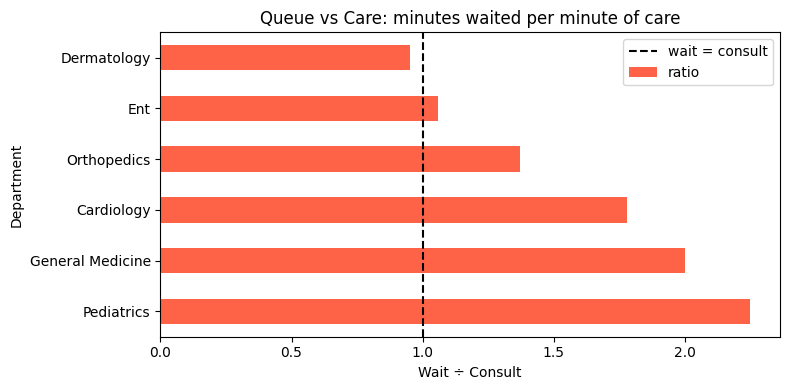

In [24]:
# YOUR CODE HERE
# Hint: your question, your code

eff = df.groupby("department").agg(
    wait=("wait_minutes", "median"),
    consult=("consult_minutes", "median")
)
eff["ratio"] = (eff["wait"] / eff["consult"]).round(2)
eff = eff.sort_values("ratio", ascending=False)

print(eff)

eff["ratio"].plot(kind="barh", figsize=(8, 4), color="tomato")
plt.axvline(1, color="black", linestyle="--", label="wait = consult")
plt.title("Queue vs Care: minutes waited per minute of care")
plt.xlabel("Wait ÷ Consult"); plt.ylabel("Department")
plt.legend(); plt.tight_layout(); plt.show()


---
## Section 5: Recommendation

**One paragraph, 120–180 words, written for the administrator (not for your trainer).** Structure: the single most important finding → the number that proves it → what to change in 2026 → one thing you would check with more data.

> *Answer* > 
> **To the Administrator,**
> 
> 
> The clinic's single biggest problem is **General Medicine**. It handles **790 visits — 33% of all outpatient traffic** — yet patients there wait a **median of 38 minutes**, more than double Dermatology's 18. On bad days the worst 10% wait **49 minutes or more**. Because every other department already runs below 26 minutes, this is not a clinic-wide capacity problem; it is concentrated in one department on one day. Monday alone brings **495 visits, 64% more than Saturday**.
> 
> **For 2026 I recommend two changes.** First, add one General Medicine doctor on Mondays and Fridays only — the two heaviest days — rather than hiring full-time. Second, lengthen appointment slots for patients over 60, since consultation time rises about **2 minutes per decade of age** (r = 0.77).
> 
> I would also separate **procedure revenue** from consultation revenue in the monthly report. Right now thirteen ₹50,000 procedures make revenue look like it is swinging between ₹1.5 L and ₹3.6 L; consultation income is actually **flat all year**. The board is reading growth that is not there.
> 
> **To be certain about the wait times, I would need appointment booking timestamps** — I cannot currently tell whether the queue is caused by overbooking, by early arrivals, or by late starts, and each needs a different fix.
>

---




## Section 6: Presentation

**Five slides** (template in `README.md`): 1 Question · 2 Data & cleaning · 3 Three findings · 4 Recommendation · 5 What I'd do next.
**Two-minute pitch** in class. **README** with the cleaning log summary and the five interview questions answered.

-> 5 -Interview question :

**1. Why keep the ₹50,000 fees when the outlier rule flagged them?**

> Because they showed the signature of **real data, not errors**. All 13 were **exactly ₹50,000** — errors are random, fixed prices are not — and all appeared only in **Orthopedics and Cardiology**, the two surgical departments. That pattern says "procedure price list," not "typo." Deleting them would have erased **₹6.5 lakh** of genuine revenue. I flagged them with `is_procedure` instead, so I could report consultation and procedure revenue separately without losing either. The IQR fence tells you a value is *unusual*; it cannot tell you it is *wrong* — that judgement needs domain knowledge.
> 

**2. How did you catch the 83 Sunday visits?**

> I applied a **real-world check**: the clinic is closed on Sundays, so any Sunday visit must be a parsing error. The cause was `format="mixed", dayfirst=True` — correct for `30/06/2025`, but on ISO dates like `2025-05-12` it **swapped month and day**, turning 12 May into 5 December. I fixed it by parsing each of the three formats **explicitly** with `errors="coerce"` and chaining `.fillna()`, then re-verified: **zero unparsed dates, zero Sundays**. The lesson: the code ran without error and still produced wrong dates — only domain knowledge caught it.
> 

**3. Why per-department median for missing fees?**

> Because department fees differ enormously — **₹520 in General Medicine versus ₹1,260 in Cardiology**. The overall median of ₹730 would have **undercharged every Cardiology visit by ₹530** and **overcharged General Medicine by ₹210**, distorting both ends. I used the **median rather than the mean** because the ₹50,000 procedures inflate Cardiology's mean to ₹2,021 — filling a routine consultation with that figure would have been badly wrong. Per-department median respects the real structure of the pricing.
> 

**4. Cardiology mean ₹2,021 vs median ₹1,260 — which goes in the annual report?**

> **Both, clearly labelled.** The **median (₹1,260)** is the honest answer to "what does a Cardiology consultation cost" — it's what a typical patient actually pays, and it matches the procedure-excluded mean of ₹1,258 almost exactly, which confirms it. The **mean (₹2,021)** is not wrong, but it answers a different question: total revenue divided by visits. Reporting it as "average consultation fee" would mislead, since six surgeries lifted it by ₹763 for 383 patients who never had one. My recommendation: report **median consultation fee** and **total procedure revenue** as two separate lines.
> 

**5. Which decision would you change with more data?**

> The **negative wait times**. I repaired 5 rows with `abs()`, assuming a sign-entry typo — reasonable, because the magnitudes (up to 37 minutes) were plausible. But it is still an assumption. With **appointment booking timestamps** I could compute the true wait as `seen_time − arrival_time` and verify each one instead of guessing. If they turned out to be something else — a system clock error, or a different field entirely — `abs()` would have quietly preserved five wrong numbers in my wait-time medians.
>

   

### The cliffhanger
`np.polyfit` fitted consult time from *one* column. The administrator asks: "Can you predict it from age **and** department **and** doctor together?" With what you know today — no. Module 16 — yes.

